In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the packages. You may need to add other packages to order to complete the assignment tasks
import pandas as pd
import numpy as np
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
#(i)
# Upload the MLData2026.csv file into your google drive.
# You may comment out (using #) the below code once the data has been imported
uploaded = files.upload()
MLData2026 = pd.read_csv(io.BytesIO(uploaded['MLData2026.csv']))

Saving MLData2026.csv to MLData2026.csv


In [ ]:
# Read the CSV file from google drive. You may need to change the pathway.
dat = pd.read_csv("/content/MLData2026.csv")

# Separate samples of non-malicious and malicious events
dat_class0 = dat[dat["Class"] == 0]  # non-malicious
dat_class1 = dat[dat["Class"] == 1]  # malicious

# Randomly select 300 samples from each class (without replacement)
# Replace 'random_state' pre-specified value with your student ID
rand_class0 = dat_class0.sample(n=300, replace=False, random_state=10729304) # <-- Replace with your student ID
rand_class1 = dat_class1.sample(n=300, replace=False, random_state=10729304) # <-- Replace with your student ID

# Combine to form working dataset
mydata = pd.concat([rand_class0, rand_class1], axis=0)

# Check dimension of sub-sample
print(mydata.shape)

(600, 14)


In [ ]:
#(ii) Extract numeric and Classified features
# Inspect column names and dtypes to identify numeric vs categorical
print("\nColumn dtypes:\n", mydata.dtypes)
# Select only numeric columns plus 'Class'
# (Adjust column names if they differ in your dataset)
numeric_cols = mydata.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)

df = mydata[numeric_cols + ['Class']].copy()
print("\nExtracted dataframe shape:", df.shape)
print(df.head())


Column dtypes:
 Assembled Payload Size               int64
DYNRiskA Score                     float64
IPV6 Traffic                        object
Response Size                      float64
Source Ping Time                     int64
Operating System                    object
Connection State                    object
Connection Rate                    float64
Ingress Router                      object
Server Response Packet Time          int64
Packet Size                          int64
Packet TTL                           int64
Source IP Concurrent Connection      int64
Class                                int64
dtype: object

Numeric columns: ['Assembled Payload Size', 'DYNRiskA Score', 'Response Size', 'Source Ping Time', 'Connection Rate', 'Server Response Packet Time', 'Packet Size', 'Packet TTL', 'Source IP Concurrent Connection', 'Class']

Extracted dataframe shape: (600, 11)
        Assembled Payload Size  DYNRiskA Score  Response Size  \
226097                   72516        0.3

In [ ]:
# (iii): Cleaned data based on Assignment 1 feedback
# Applied cleaning steps that was flagged in Assignment 1 feedback,
# removed known erroneous values, fixing types, etc.

# setting limits (thresholds) so that any data outside a realistic range is adjusted.
# df['SomeFeature'] = df['SomeFeature'].clip(lower=0)

# Check for duplicates
print("\nDuplicates:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicates: 0


In [ ]:
# (iv): Removing incomplete data or variable
print("\nMissing values before dropna:\n", df.isnull().sum())
df_clean = df.dropna().reset_index(drop=True)
print("Shape after dropna:", df_clean.shape)

# Separate features and class label
X = df_clean[numeric_cols]   # numeric features only (for PCA)
y = df_clean.loc[:, 'Class'].iloc[:, 0] # Select the first 'Class' column to ensure 'y' is a Series

print("\nClass distribution:\n", y.value_counts())


Missing values before dropna:
 Assembled Payload Size              0
DYNRiskA Score                      0
Response Size                      42
Source Ping Time                    0
Connection Rate                     0
Server Response Packet Time         0
Packet Size                         0
Packet TTL                          0
Source IP Concurrent Connection     0
Class                               0
Class                               0
dtype: int64
Shape after dropna: (558, 11)

Class distribution:
 Class
0    280
1    278
Name: count, dtype: int64


Feature standard deviations:
 Assembled Payload Size              16709.759
DYNRiskA Score                          0.116
Response Size                      100604.013
Source Ping Time                       49.216
Connection Rate                       312.618
Server Response Packet Time            71.394
Packet Size                            28.118
Packet TTL                              9.296
Source IP Concurrent Connection         4.920
Class                                   0.500
Class                                   0.500
dtype: float64

Feature ranges:
 Assembled Payload Size              80604.000
DYNRiskA Score                          0.609
Response Size                      569222.000
Source Ping Time                      319.000
Connection Rate                      2084.632
Server Response Packet Time           341.000
Packet Size                           198.000
Packet TTL                             74.000
Source IP Concurrent Connection        23.000
Class            

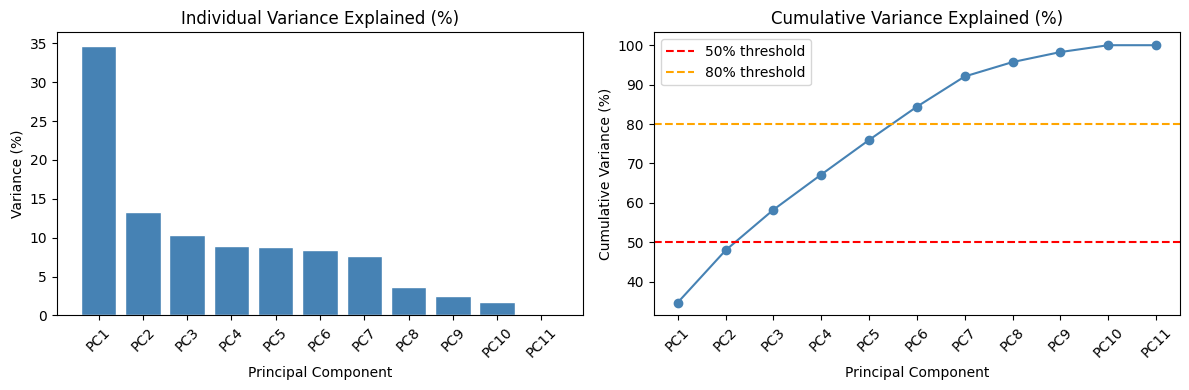

In [ ]:
# (v): Perform PCA:
# Should we standardise or not?
# PCA is sensitive to scale: features with larger ranges dominate the
# variance. If features have very different units or magnitudes,
# standardisation (zero mean, unit variance) is essential.
# Inspect the standard deviations:
print("Feature standard deviations:\n", X.std().round(3))
print("\nFeature ranges:\n", (X.max() - X.min()).round(3))

# Decision: if SDs differ substantially → scale. (Explain your choice below.)
# Here we standardise as best practice for PCA.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA for all components
pca = PCA()
pca.fit(X_scaled)

# Variance explained
explained_var       = pca.explained_variance_ratio_
cumulative_var      = np.cumsum(explained_var)
n_components        = len(explained_var)
component_labels    = [f'PC{i+1}' for i in range(n_components)]

# Display as a table
var_df = pd.DataFrame({
    'Component':   component_labels,
    'Individual':  explained_var.round(3),
    'Cumulative':  cumulative_var.round(3)
})
print("\nVariance Explained:\n")
print(var_df.to_string(index=False))

# How many PCs explain at least 50% of variance?
n_50 = np.argmax(cumulative_var >= 0.50) + 1
print(f"\n→ {n_50} principal component(s) explain at least 50% of variance.")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(component_labels, explained_var * 100, color='steelblue', edgecolor='white')
axes[0].set_title('Individual Variance Explained (%)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance (%)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(component_labels, cumulative_var * 100, marker='o', color='steelblue')
axes[1].axhline(50, color='red', linestyle='--', label='50% threshold')
axes[1].axhline(80, color='orange', linestyle='--', label='80% threshold')
axes[1].set_title('Cumulative Variance Explained (%)')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Interpreting the coefficients or loadings for PC1, PC2, PC3
# Loadings = coefficients that define each principal component
loadings = pd.DataFrame(
    pca.components_[:3].T,          # First 3 PCs, transposed
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)
print("\nLoadings (to 3 decimal places):\n")
print(loadings.round(3).to_string())



Loadings (to 3 decimal places):

                                   PC1    PC2    PC3
Assembled Payload Size          -0.439  0.073 -0.045
DYNRiskA Score                   0.285  0.473  0.011
Response Size                   -0.017 -0.050  0.585
Source Ping Time                -0.006  0.202 -0.327
Connection Rate                 -0.178  0.368  0.139
Server Response Packet Time      0.458  0.046 -0.004
Packet Size                     -0.017 -0.068  0.637
Packet TTL                       0.012  0.140  0.347
Source IP Concurrent Connection  0.010  0.745  0.053
Class                            0.492 -0.070  0.018
Class                            0.492 -0.070  0.018


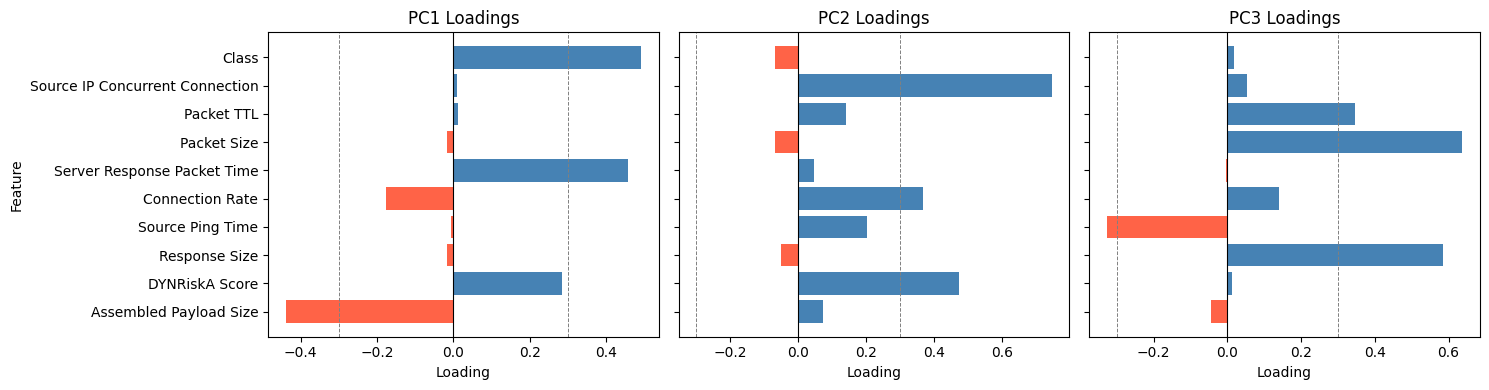


Key drivers for PC1 (|loading| > 0.3):
Class                          0.492
Class                          0.492
Server Response Packet Time    0.458
Assembled Payload Size        -0.439
Name: PC1, dtype: float64

Key drivers for PC2 (|loading| > 0.3):
Source IP Concurrent Connection    0.745
DYNRiskA Score                     0.473
Connection Rate                    0.368
Name: PC2, dtype: float64

Key drivers for PC3 (|loading| > 0.3):
Packet Size         0.637
Response Size       0.585
Packet TTL          0.347
Source Ping Time   -0.327
Name: PC3, dtype: float64


In [ ]:
# Visualise loadings
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors_pos = 'steelblue'
colors_neg = 'tomato'

for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
    vals = loadings[pc]
    bar_colors = [colors_pos if v >= 0 else colors_neg for v in vals]
    ax.barh(loadings.index, vals, color=bar_colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.axvline( 0.3, color='gray', linestyle='--', linewidth=0.7, label='±0.3 threshold')
    ax.axvline(-0.3, color='gray', linestyle='--', linewidth=0.7)
    ax.set_title(f'{pc} Loadings')
    ax.set_xlabel('Loading')

axes[0].set_ylabel('Feature')
plt.tight_layout()
plt.show()
# Key drivers: features with |loading| > 0.3
for pc in ['PC1', 'PC2', 'PC3']:
    drivers = loadings[pc][loadings[pc].abs() > 0.3].sort_values(key=abs, ascending=False)
    print(f"\nKey drivers for {pc} (|loading| > 0.3):\n{drivers.round(3)}")

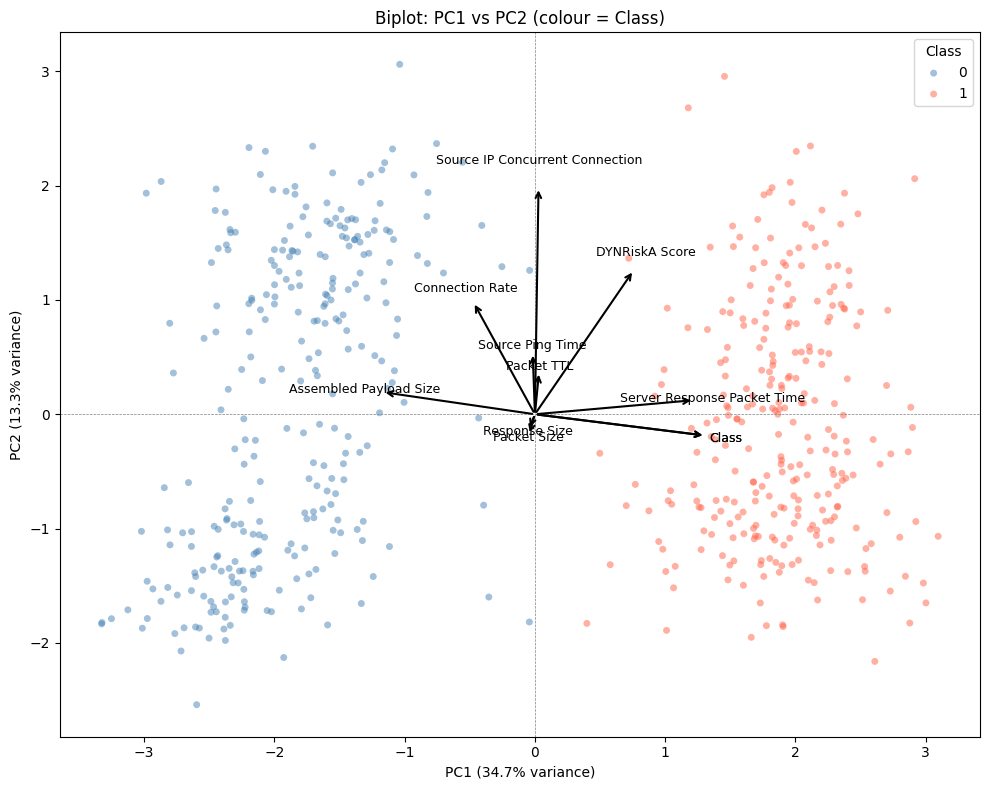

In [ ]:
#(vi): Biplot for PC1 vs PC2
# Transform data into PCA space
X_pca = pca.transform(X_scaled)

# Colour-code by Class
classes      = y.unique()
palette      = {cls: col for cls, col in zip(sorted(classes),
                ['steelblue', 'tomato', 'green', 'purple', 'orange'])}
point_colors = y.map(palette)

fig, ax = plt.subplots(figsize=(10, 8))

# PCA scatter plot scores
for cls in sorted(classes):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=palette[cls], label=str(cls),
               alpha=0.5, s=25, edgecolors='none')
# --- Loadings arrows (loading plot) ---
# Scale arrows to be visible relative to score cloud
scale = np.max(np.abs(X_pca[:, :2])) * 0.8
feature_names = X.columns.tolist()

for i, feat in enumerate(feature_names):
    lx = pca.components_[0, i] * scale
    ly = pca.components_[1, i] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(lx * 1.12, ly * 1.12, feat, fontsize=9,
            ha='center', va='center', color='black')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}% variance)')
ax.set_title('Biplot: PC1 vs PC2 (colour = Class)')
ax.legend(title='Class', loc='upper right')
plt.tight_layout()
plt.show()

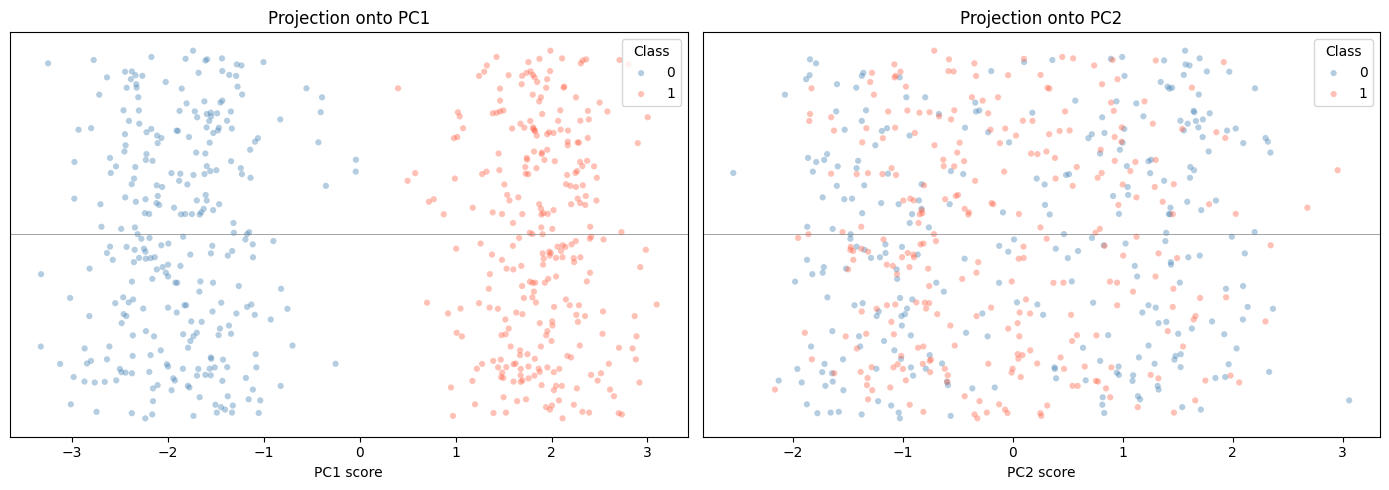


Key features driving PC1 (|loading| > 0.3):
Class                          0.492
Class                          0.492
Server Response Packet Time    0.458
Assembled Payload Size        -0.439


In [ ]:
# (vii): PC1 vs PC2 malicious activity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Project onto PC1 axis (strip chart / jitter)
for ax, pc_idx, pc_name in zip(axes, [0, 1], ['PC1', 'PC2']):
    for cls in sorted(classes):
        mask = y == cls
        scores = X_pca[mask, pc_idx]
        jitter = np.random.default_rng(42).uniform(-0.3, 0.3, size=len(scores))
        ax.scatter(scores, jitter,
                   c=palette[cls], label=str(cls),
                   alpha=0.4, s=20, edgecolors='none')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel(f'{pc_name} score')
    ax.set_yticks([])
    ax.set_title(f'Projection onto {pc_name}')
    ax.legend(title='Class')

plt.tight_layout()
plt.show()

# Key features for the chosen PC (|loading| > 0.3)
# *** After examining the plots above, decide which PC separates
#     malicious vs non-malicious better, then update CHOSEN_PC below. ***
CHOSEN_PC = 'PC1'   # <-- update based on YOUR visual assessment

key_features = loadings[CHOSEN_PC][loadings[CHOSEN_PC].abs() > 0.3]
key_features = key_features.sort_values(key=abs, ascending=False)
print(f"\nKey features driving {CHOSEN_PC} (|loading| > 0.3):")
print(key_features.round(3).to_string())